In [16]:
import geopandas as gpd
from geodatasets import get_path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from shapely.geometry import Point

import pandas as pd
import numpy as np

import glob
import os
import re

In [17]:
manhattan_shapes = pd.read_csv('./output/manhattan_shapes.csv')
manhattan_shapes['ZIP Code'] = manhattan_shapes['ZIP Code'].astype(str)

In [18]:
tenure = pd.read_csv(os.path.join('tenure', 'tenure.csv'))
tenure_transposed = tenure.T

def extract_zip_code(row):
    # Extract the ZIP code from the row index
    return row.name.split(' ')[1].split("!!")[0]

tenure_transposed['ZIP Code'] = tenure_transposed.apply(extract_zip_code, axis=1)
tenure_transposed.drop(tenure_transposed.index[0], inplace=True)

In [19]:
# Define the new column names
new_column_names = [
    "Total",
    "Owner Occupied",
    "Owner occupied: Moved in 2021 or later",
    "Owner occupied: Moved in 2018 to 2020",
    "Owner occupied: Moved in 2010 to 2017",
    "Owner occupied: Moved in 2000 to 2009",
    "Owner occupied: Moved in 1990 to 1999",
    "Owner occupied: Moved in 1989 or earlier",
    "Rent Occupied",
    "Renter occupied: Moved in 2021 or later",
    "Renter occupied: Moved in 2018 to 2020",
    "Renter occupied: Moved in 2010 to 2017",
    "Renter occupied: Moved in 2000 to 2009",
    "Renter occupied: Moved in 1990 to 1999",
    "Renter occupied: Moved in 1989 or earlier",
]

# Append the ZIP Code column name at the end
new_column_names.append("ZIP Code")

# Assign the new column names
tenure_transposed.columns = new_column_names
tenure_transposed = tenure_transposed.drop_duplicates(subset='ZIP Code', keep='first')

In [20]:
tenure_transposed.reset_index(drop=True, inplace=True)
tenure_transposed.to_csv(os.path.join('tenure', 'tenure_transposed.csv'), index=False)

In [21]:
tenure_transposed

,Total,Owner Occupied,Owner occupied: Moved in 2021 or later,Owner occupied: Moved in 2018 to 2020,Owner occupied: Moved in 2010 to 2017,Owner occupied: Moved in 2000 to 2009,Owner occupied: Moved in 1990 to 1999,Owner occupied: Moved in 1989 or earlier,Rent Occupied,Renter occupied: Moved in 2021 or later,Renter occupied: Moved in 2018 to 2020,Renter occupied: Moved in 2010 to 2017,Renter occupied: Moved in 2000 to 2009,Renter occupied: Moved in 1990 to 1999,Renter occupied: Moved in 1989 or earlier,ZIP Code
0,17,3,0,0,0,3,0,0,14,0,0,14,0,0,0,06390
1,"15,097","3,570",258,715,"1,106",787,372,332,"11,527","2,319","3,526","3,241","1,181",609,651,10001
2,"35,771","6,660",339,597,"1,506","1,488","1,402","1,328","29,111","2,538","5,930","6,925","4,996","3,300","5,422",10002
3,"25,080","8,701",628,844,"2,085","1,970","1,734","1,440","16,379","3,313","4,912","3,282","1,318","1,371","2,183",10003
4,"1,775",630,47,243,195,141,0,4,"1,145",217,452,435,14,27,0,10004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1819,521,396,11,35,78,97,102,73,125,28,45,25,3,4,20,14898
1820,"5,550","2,950",125,321,530,976,353,645,"2,600",431,982,720,304,131,32,14901
1821,"3,071","2,053",77,221,714,188,330,523,"1,018",249,265,240,168,69,27,14903
1822,"6,419","4,111",257,468,867,896,526,"1,097","2,308",418,839,779,213,21,38,14904


In [22]:
gdf_tenure = manhattan_shapes.merge(tenure_transposed, left_on='ZIP Code', right_on='ZIP Code', how='left')

In [23]:
from shapely import wkt
import geopandas as gpd

# Convert the 'geometry' column from WKT text to real shapely objects
gdf_tenure['geometry'] = gdf_tenure['geometry'].apply(wkt.loads)

# Now make it a GeoDataFrame
gdf_tenure = gpd.GeoDataFrame(gdf_tenure, geometry='geometry')

# (Optional but good practice) Set the CRS
gdf_tenure.set_crs(epsg=4326, inplace=True)  # WGS84 latitude/longitude

,pop_est,geometry,ZIP Code,SAFMR 1BR,Total,Owner Occupied,Owner occupied: Moved in 2021 or later,Owner occupied: Moved in 2018 to 2020,Owner occupied: Moved in 2010 to 2017,Owner occupied: Moved in 2000 to 2009,Owner occupied: Moved in 1990 to 1999,Owner occupied: Moved in 1989 or earlier,Rent Occupied,Renter occupied: Moved in 2021 or later,Renter occupied: Moved in 2018 to 2020,Renter occupied: Moved in 2010 to 2017,Renter occupied: Moved in 2000 to 2009,Renter occupied: Moved in 1990 to 1999,Renter occupied: Moved in 1989 or earlier
0,23072.0,"POLYGON ((-73.98774 40.74407, -73.98819 40.743...",10001,3220.0,"15,097","3,570",258,715,"1,106",787,372,332,"11,527","2,319","3,526","3,241","1,181",609,651
1,74993.0,"POLYGON ((-73.9975 40.71407, -73.99709 40.7146...",10002,2210.0,"35,771","6,660",339,597,"1,506","1,488","1,402","1,328","29,111","2,538","5,930","6,925","4,996","3,300","5,422"
2,54682.0,"POLYGON ((-73.98864 40.72293, -73.98876 40.722...",10003,3500.0,"25,080","8,701",628,844,"2,085","1,970","1,734","1,440","16,379","3,313","4,912","3,282","1,318","1,371","2,183"
3,39363.0,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...",10026,2270.0,"15,537","3,574",329,335,"1,284","1,141",262,223,"11,963","1,611","2,325","2,968","2,090","1,697","1,272"
4,3028.0,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...",10004,3320.0,"1,775",630,47,243,195,141,0,4,"1,145",217,452,435,14,27,0
5,8831.0,"POLYGON ((-74.00783 40.70309, -74.00786 40.703...",10005,3500.0,"5,156",880,40,193,349,181,117,0,"4,276","1,151","2,160",683,137,87,58
6,3454.0,"POLYGON ((-74.01251 40.70677, -74.01325 40.705...",10006,3500.0,"2,305",402,31,91,196,84,0,0,"1,903",675,471,567,141,49,0
7,7023.0,"POLYGON ((-74.00998 40.70981, -74.01123 40.710...",10007,2880.0,"3,309","1,159",211,259,273,182,61,173,"2,150",642,632,658,138,48,32
8,57925.0,"POLYGON ((-73.98864 40.72293, -73.98859 40.723...",10009,2450.0,"30,025","2,687",136,346,572,296,284,"1,053","27,338","3,519","7,306","5,126","2,849","3,499","5,039"
9,33730.0,"POLYGON ((-73.97979 40.73496, -73.97988 40.735...",10010,2840.0,"16,192","4,453",204,709,"1,065",754,755,966,"11,739","2,293","3,052","2,743",797,960,"1,894"


In [24]:
def clean_numeric_column(series):
    def clean_value(val):
        if pd.isnull(val):
            return np.nan
        # Remove commas and unwanted characters (keep digits, decimal point, minus sign)
        cleaned = re.sub(r"[^\d\.\-]", "", str(val))
        try:
            return float(cleaned)
        except ValueError:
            return np.nan

    return series.apply(clean_value)

In [25]:
gdf_tenure['Renter occupied: Moved in 1989 or earlier'] = clean_numeric_column(gdf_tenure['Renter occupied: Moved in 1989 or earlier'])
gdf_tenure['Renter occupied: Moved in 1990 to 1999'] = clean_numeric_column(gdf_tenure['Renter occupied: Moved in 1990 to 1999'])


gdf_tenure['Total'] = clean_numeric_column(
    gdf_tenure['Total']
)
gdf_tenure['1990_percentage'] = gdf_tenure['Renter occupied: Moved in 1990 to 1999'] / gdf_tenure['Total']
gdf_tenure['1989_percentage'] = gdf_tenure['Renter occupied: Moved in 1989 or earlier'] / gdf_tenure['Total']

In [26]:
spaces = pd.read_csv(os.path.join('output', 'spaces.csv'))

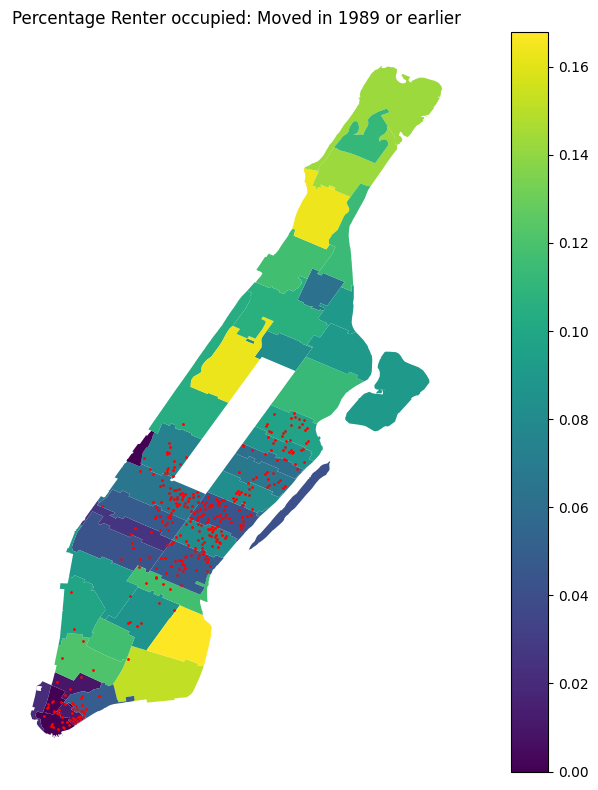

In [27]:
cmap = plt.cm.viridis
fig, ax = plt.subplots(figsize=(10, 8))

gdf_tenure.plot(
    ax=ax,
    column='1989_percentage',
    cmap=cmap,
    legend=True,
    legend_kwds={'orientation': "vertical"}
)

geometry = [Point(lon, lat) for lon, lat in zip(spaces['Longitude'], spaces['Latitude'])]
lat_lon_gdf = gpd.GeoDataFrame(spaces, geometry=geometry)

# Plot lat/long data points
lat_lon_gdf.plot(ax=ax, color='red', markersize=1, label="Lat/Lon Points")

plt.title("Percentage Renter occupied: Moved in 1989 or earlier")
plt.axis('off')
plt.tight_layout()
plt.show()

In [28]:
# Select only the desired columns
columns_to_keep = ['ZIP Code', '1989_percentage']
output_tenure = gdf_tenure[columns_to_keep].copy()

# Save to CSV
output_tenure.to_csv('./output/tenure.csv', index=False)